# Modeling the ±60° WAC_EMP edge-brightening anomaly

`wac_emp_seam_investigation.py` traced the horizontal-line artifact in two `trntest1` entries to a
real edge-brightening defect in both WAC_EMP source tiles that meet at the ±60° equirect/polar
boundary (`WAC_EMP_643NM_E300S1350_304P`, `WAC_EMP_643NM_P900S0000_304P`): the equirect tile's own
last valid native row reads +21%/+12% bright relative to its own interior, and the polar tile has a
smaller but real +5.3% version of the same thing right at its own edge.

This notebook profiles that brightening precisely -- mean reflectance ± standard error, binned by
each pixel's own signed distance from the boundary in native pixels (0.1px bins, out to ±15px), one
plot per tile -- to see whether the shape is something a correction factor could subtract off,
versus how much has to be masked outright. Both known-bad entries mosaic the same tile pair (already
confirmed in `wac_emp_seam_investigation.py`), so there is exactly one tile pair to profile here, not
one per entry. It also calls `ortho_wac_emp`'s own correction functions directly on a copy of this
same data, so the "corrected" curve shown further down is the actual production behavior, not a
reimplementation.

Distance is signed so both plots share one convention: **negative = equatorward of the boundary**
(inside the equirect tile's own valid area), **positive = poleward** (inside the polar tile's own
valid area), zero = the ±60° line itself. Each tile only has valid data on its own side of that line
-- so each plot is expected to populate only half its x-range and stay empty on the other half. That
asymmetry is the real tile geometry, not a bug in the binning.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.transform import array_bounds
from rasterio.warp import transform as warp_transform
from rasterio.windows import Window
from rasterio.windows import transform as window_transform
from scipy.optimize import curve_fit

import trntest
from trntest import cache
from trntest.config import MOON_RADIUS_M
from trntest.geo_utils import geographic_crs
from trntest.ortho_wac_emp import wac_emp_tile_ids_for_bbox
from trntest.wac_emp_edge_correction import (
    mask_and_correct_polar_edge,
    mask_equirect_edge_row,
)

config = trntest.load_config()
dataset = trntest.TrnTestDataSet.open(config.output_dir / "trntest1", config)
geo_crs = geographic_crs()

BAD_ENTRIES = ["M1314469291CE", "M1314314993CE"]  # trntest1 indices 201 and 3
BOUNDARY_LAT_DEG = -60.0
MAX_DISTANCE_PX = 15.0  # wide enough to cover the production correction's own 8-13px reference band
BIN_WIDTH_PX = 0.1
SENTINEL_MAGNITUDE_THRESHOLD = -1e30  # real reflectance is never anywhere near this -- robust against
# the tiles' embedded nodata tag not always comparing equal to itself bit-for-bit (a PDS3-label
# precision quirk noted in wac_emp_seam_investigation.py).

## Locate the two source tiles

In [2]:
tile_id_sets = set()
for product_id in BAD_ENTRIES:
    entry = dataset[product_id]
    path = entry.per_image_config.output_dir / "ortho_wac_emp.tif"
    with rasterio.open(path) as src:
        bounds = array_bounds(src.height, src.width, src.transform)
    tile_ids = wac_emp_tile_ids_for_bbox(
        bounds, entry.row["center_lon_deg"], entry.row["center_lat_deg"], MOON_RADIUS_M
    )
    tile_id_sets.add(frozenset(tile_ids))
assert len(tile_id_sets) == 1, f"expected one shared tile pair across both entries, got {tile_id_sets}"
tile_ids = next(iter(tile_id_sets))
equirect_tile_id = next(t for t in tile_ids if "P900" not in t)
polar_tile_id = next(t for t in tile_ids if "P900" in t)
equirect_path = cache.fetch_wac_emp_tile(equirect_tile_id, config.cache_root, config.wac_emp_base_url)
polar_path = cache.fetch_wac_emp_tile(polar_tile_id, config.cache_root, config.wac_emp_base_url)
print(equirect_tile_id, equirect_path)
print(polar_tile_id, polar_path)

WAC_EMP_643NM_E300S1350_304P /workspace/cache/pds_wac_emp/WAC_EMP_643NM_E300S1350_304P.IMG
WAC_EMP_643NM_P900S0000_304P /workspace/cache/pds_wac_emp/WAC_EMP_643NM_P900S0000_304P.IMG


## Binning helper

Shared by both tiles: given every valid pixel's own signed distance from the boundary (in native
pixels) and its value, bin distance into `BIN_WIDTH_PX`-wide bins over `[-MAX_DISTANCE_PX,
MAX_DISTANCE_PX]` and report each bin's mean and standard error (`std / sqrt(n)`).

In [3]:
def _bin_profile(distance_px, value, bin_width=BIN_WIDTH_PX, max_distance=MAX_DISTANCE_PX):
    bin_edges = np.arange(-max_distance, max_distance + bin_width, bin_width)
    bin_idx = np.digitize(distance_px, bin_edges)
    centers, means, sems, counts = [], [], [], []
    for b in range(1, len(bin_edges)):
        mask = bin_idx == b
        n = int(mask.sum())
        if n == 0:
            continue
        vals = value[mask]
        centers.append((bin_edges[b - 1] + bin_edges[b]) / 2)
        means.append(vals.mean())
        sems.append(vals.std(ddof=1) / math.sqrt(n) if n > 1 else 0.0)
        counts.append(n)
    return np.array(centers), np.array(means), np.array(sems), np.array(counts)

## Equirect tile: signed distance from the boundary

This tile's CRS is Equidistant Cylindrical (`proj=eqc`) at `standard_parallel_1=0` -- by
construction, meridian (row/northing) spacing is exactly the tile's own nominal pixel size
everywhere, with none of the latitude-dependent scale distortion the polar tile has near its own
edge. So the exact fractional row at latitude -60° can be computed directly from the tile's own
affine transform and a single forward-projected point, with no per-pixel reprojection needed.

In [4]:
with rasterio.open(equirect_path) as src:
    equirect_transform = src.transform
    equirect_crs = src.crs
    equirect_height, equirect_width = src.height, src.width
    equirect_nodata = src.nodata

equirect_pixel_size_m = abs(equirect_transform.e)
assert math.isclose(abs(equirect_transform.a), equirect_pixel_size_m)  # square pixels, assumed below

(x_boundary_m,), (y_boundary_m,) = warp_transform(geo_crs, equirect_crs, [0.0], [BOUNDARY_LAT_DEG])
_, boundary_row = ~equirect_transform * (x_boundary_m, y_boundary_m)
print(
    f"{equirect_tile_id}: pixel size = {equirect_pixel_size_m} m, "
    f"boundary row = {boundary_row:.2f} (of {equirect_height})"
)

WAC_EMP_643NM_E300S1350_304P: pixel size = 99.747863237334 m, boundary row = 18240.00 (of 18240)


Read a window of full-width rows straddling `boundary_row ± MAX_DISTANCE_PX` -- clipped to the
tile's own bounds rather than padded, since the boundary sits at the tile's own last valid row and
no rows exist past it.

In [5]:
row_lo = max(0, int(math.floor(boundary_row - MAX_DISTANCE_PX - 1)))
row_hi = min(equirect_height, int(math.ceil(boundary_row + MAX_DISTANCE_PX + 1)))
with rasterio.open(equirect_path) as src:
    equirect_strip = src.read(1, window=Window(0, row_lo, equirect_width, row_hi - row_lo))

rows = np.arange(row_lo, row_hi)
distance_px_per_row = rows - boundary_row  # negative = equatorward (this tile's own interior)
valid = equirect_strip > SENTINEL_MAGNITUDE_THRESHOLD
distance_px_flat = np.broadcast_to(distance_px_per_row[:, None], equirect_strip.shape)[valid]
value_flat = equirect_strip[valid]
print(f"{equirect_tile_id}: {value_flat.size} valid samples across {row_hi - row_lo} rows")

eq_centers, eq_means, eq_sems, eq_counts = _bin_profile(distance_px_flat, value_flat)

WAC_EMP_643NM_E300S1350_304P: 465120 valid samples across 17 rows


### Same profile, after `ortho_wac_emp`'s own correction

Calling the actual production functions (`mask_equirect_edge_row`/
`mask_and_correct_polar_edge`), not a reimplementation, on a copy of this same window --
exactly what a real reprojection call now does to this tile's own native pixels before resampling,
so this profile is directly comparable to what a corrected `ortho_wac_emp.tif` mosaic actually
contains.

In [6]:
equirect_strip_corrected = equirect_strip.copy()
equirect_strip_transform = window_transform(Window(0, row_lo, equirect_width, row_hi - row_lo), equirect_transform)
mask_equirect_edge_row(equirect_strip_corrected, equirect_strip_transform, equirect_crs, MOON_RADIUS_M, equirect_nodata)

valid_corrected = equirect_strip_corrected > SENTINEL_MAGNITUDE_THRESHOLD
distance_px_flat_corrected = np.broadcast_to(distance_px_per_row[:, None], equirect_strip_corrected.shape)[
    valid_corrected
]
value_flat_corrected = equirect_strip_corrected[valid_corrected]
print(f"{equirect_tile_id}: {value_flat_corrected.size} valid samples after correction (was {value_flat.size})")

eq_centers_corrected, eq_means_corrected, eq_sems_corrected, eq_counts_corrected = _bin_profile(
    distance_px_flat_corrected, value_flat_corrected
)

WAC_EMP_643NM_E300S1350_304P: 437760 valid samples after correction (was 465120)


## Polar tile: signed distance from the boundary

The polar tile's edge is a circle around the pole, not a row. Following
`wac_emp_seam_investigation.py`'s radial-profile approach, radius is measured directly in native
pixel-index units (row/col differences from the pole, found by inverting the tile's own affine
transform at its own projected origin) rather than converted through latitude -- this tile's own
scale is only exactly true at the pole (`lat_ts=-90`), not at ±60°, so a latitude-based conversion
would itself be distorted right where we're measuring. The boundary radius is just the one point
(lon=0, lat=-60°) forward-projected into the same tile CRS.

In [7]:
with rasterio.open(polar_path) as src:
    polar_transform = src.transform
    polar_crs = src.crs
    polar_height, polar_width = src.height, src.width
    polar_nodata = src.nodata
    center_col, center_row = (~polar_transform) * (0.0, 0.0)

polar_pixel_size_m = abs(polar_transform.a)
assert math.isclose(abs(polar_transform.e), polar_pixel_size_m)

(x_boundary_m,), (y_boundary_m,) = warp_transform(geo_crs, polar_crs, [0.0], [BOUNDARY_LAT_DEG])
boundary_radius_px = math.hypot(x_boundary_m, y_boundary_m) / polar_pixel_size_m
print(
    f"{polar_tile_id}: pole at (col={center_col:.2f}, row={center_row:.2f}), "
    f"boundary radius = {boundary_radius_px:.2f} px"
)

WAC_EMP_643NM_P900S0000_304P: pole at (col=9335.00, row=9335.00), boundary radius = 9334.23 px


Reading the whole tile at once just to keep a thin ring near the boundary would mean holding an
18669×18669 float32 array (~1.3GB) in memory for no reason -- instead, scan the raster in
horizontal strips and only keep pixels whose radius already falls within `MAX_DISTANCE_PX` of the
boundary before accumulating.

In [8]:
STRIP_HEIGHT = 512
distance_chunks, value_chunks = [], []
distance_chunks_corrected, value_chunks_corrected = [], []
with rasterio.open(polar_path) as src:
    for row0 in range(0, polar_height, STRIP_HEIGHT):
        row1 = min(polar_height, row0 + STRIP_HEIGHT)
        strip = src.read(1, window=Window(0, row0, polar_width, row1 - row0))
        rows = np.arange(row0, row1).reshape(-1, 1) - center_row
        cols = np.arange(polar_width).reshape(1, -1) - center_col
        radius_px = np.sqrt(rows.astype(np.float64) ** 2 + cols.astype(np.float64) ** 2)
        distance_px = boundary_radius_px - radius_px  # positive = poleward, matches the equirect sign
        keep = (strip > SENTINEL_MAGNITUDE_THRESHOLD) & (np.abs(distance_px) <= MAX_DISTANCE_PX)
        if keep.any():
            distance_chunks.append(distance_px[keep])
            value_chunks.append(strip[keep])

        # Same production correction as the equirect side above, applied to a copy of this same strip.
        strip_corrected = strip.copy()
        strip_transform = window_transform(Window(0, row0, polar_width, row1 - row0), polar_transform)
        mask_and_correct_polar_edge(strip_corrected, strip_transform, polar_crs, MOON_RADIUS_M, polar_nodata)
        keep_corrected = (strip_corrected > SENTINEL_MAGNITUDE_THRESHOLD) & (np.abs(distance_px) <= MAX_DISTANCE_PX)
        if keep_corrected.any():
            distance_chunks_corrected.append(distance_px[keep_corrected])
            value_chunks_corrected.append(strip_corrected[keep_corrected])

distance_px_flat = np.concatenate(distance_chunks)
value_flat = np.concatenate(value_chunks)
print(f"{polar_tile_id}: {value_flat.size} valid samples within ±{MAX_DISTANCE_PX}px of the boundary")

pol_centers, pol_means, pol_sems, pol_counts = _bin_profile(distance_px_flat, value_flat)

distance_px_flat_corrected = np.concatenate(distance_chunks_corrected)
value_flat_corrected = np.concatenate(value_chunks_corrected)
print(f"{polar_tile_id}: {value_flat_corrected.size} valid samples after correction (was {value_flat.size})")

pol_centers_corrected, pol_means_corrected, pol_sems_corrected, pol_counts_corrected = _bin_profile(
    distance_px_flat_corrected, value_flat_corrected
)

WAC_EMP_643NM_P900S0000_304P: 879015 valid samples within ±15.0px of the boundary
WAC_EMP_643NM_P900S0000_304P: 761656 valid samples after correction (was 879015)


## Near-boundary profile, as numbers

The plots below make the shape easy to see, but the actual bin means/sample counts are worth
having in text too -- particularly to check how many samples back each point, since a bin that
straddles the tile's own true (sub-pixel) edge can have very few.

In [9]:
def _print_profile(label, centers, means, sems, counts, lo, hi):
    print(f"{label}:")
    for c, m, s, n in zip(centers, means, sems, counts, strict=True):
        if lo <= c <= hi:
            print(f"  {c:6.2f}  n={n:7d}  mean={m:.5f}  sem={s:.6f}")


_print_profile("equirect", eq_centers, eq_means, eq_sems, eq_counts, -3, 1)
print()
_print_profile("polar", pol_centers, pol_means, pol_sems, pol_counts, -1, 3)

equirect:
   -2.95  n=  27360  mean=0.11367  sem=0.000132
   -1.95  n=  27360  mean=0.11349  sem=0.000131
   -0.95  n=  27360  mean=0.12145  sem=0.000218

polar:
   -0.75  n=     10  mean=0.12503  sem=0.005503
   -0.65  n=    698  mean=0.13059  sem=0.000798
   -0.55  n=   1340  mean=0.13164  sem=0.000580
   -0.45  n=   1594  mean=0.13249  sem=0.000586
   -0.35  n=   1930  mean=0.13223  sem=0.000525
   -0.25  n=   2252  mean=0.13210  sem=0.000478
   -0.15  n=   2620  mean=0.12974  sem=0.000424
   -0.05  n=   2812  mean=0.12845  sem=0.000403
    0.05  n=   3030  mean=0.12703  sem=0.000391
    0.15  n=   3282  mean=0.12683  sem=0.000376
    0.25  n=   3718  mean=0.12643  sem=0.000407
    0.35  n=   3820  mean=0.12543  sem=0.000361
    0.45  n=   4511  mean=0.12593  sem=0.000353
    0.55  n=   4392  mean=0.12304  sem=0.000350
    0.65  n=   4950  mean=0.12157  sem=0.000339
    0.75  n=   5848  mean=0.12287  sem=0.000335
    0.85  n=   6024  mean=0.12265  sem=0.000321
    0.95  n=   5848  m

## Fitting the polar tile's near-boundary shape

The polar profile's shape -- a sharp peak right at the boundary, an undershoot a couple of pixels
in, then a slow relaxation back to baseline -- reads as a damped oscillation (ringing) rather than a
one-sided bump, consistent with the edge-ringing hypothesis above (a sharpening/resampling step
reacting to the tile's own hard data boundary). A damped cosine captures that shape in 4 free
parameters:

`f(x) = baseline + amplitude * exp(-x / tau) * cos(omega * x)`

with the oscillation's own center pinned to `x = 0` (the boundary itself) rather than left free --
a 5th free parameter isn't needed since the boundary location is already known geometrically, not
something to fit. Fit only over `x >= 0`: the handful of bins at `x < 0` sit on the tile's own true,
sub-pixel raster edge and have as few as 10 samples -- too noisy to trust in a least-squares fit
(`MIN_FIT_BIN_COUNT` drops any bin with fewer samples than the typical bin has, not just the
negative-x ones, in case another sparse bin turns up elsewhere in range).

In [10]:
MIN_FIT_BIN_COUNT = 100


def _damped_cosine(x, baseline, amplitude, tau, omega):
    return baseline + amplitude * np.exp(-x / tau) * np.cos(omega * x)


fit_mask = (pol_centers >= 0) & (pol_counts >= MIN_FIT_BIN_COUNT)
x_fit, y_fit, sigma_fit = pol_centers[fit_mask], pol_means[fit_mask], pol_sems[fit_mask]

initial_guess = [0.120, 0.012, 2.0, 1.5]  # baseline, amplitude, tau (px), omega (rad/px)
fit_params, fit_cov = curve_fit(_damped_cosine, x_fit, y_fit, p0=initial_guess, sigma=sigma_fit, absolute_sigma=True)
fit_errs = np.sqrt(np.diag(fit_cov))
baseline_fit, amplitude_fit, tau_fit, omega_fit = fit_params

fit_residuals = y_fit - _damped_cosine(x_fit, *fit_params)
fit_chi2 = float(np.sum((fit_residuals / sigma_fit) ** 2))
fit_dof = len(x_fit) - len(fit_params)
print(f"baseline  = {baseline_fit:.5f} ± {fit_errs[0]:.5f}")
print(f"amplitude = {amplitude_fit:.5f} ± {fit_errs[1]:.5f}")
print(f"tau       = {tau_fit:.3f} ± {fit_errs[2]:.3f} px")
print(f"omega     = {omega_fit:.3f} ± {fit_errs[3]:.3f} rad/px  (period = {2 * np.pi / omega_fit:.2f} px)")
print(f"chi2/dof  = {fit_chi2:.1f} / {fit_dof} = {fit_chi2 / fit_dof:.2f}")

baseline  = 0.11989 ± 0.00003
amplitude = 0.00698 ± 0.00021
tau       = 1.573 ± 0.073 px
omega     = 0.916 ± 0.019 rad/px  (period = 6.86 px)
chi2/dof  = 170.3 / 146 = 1.17


## Plot: mean reflectance ± standard error vs. signed distance from the boundary

Original (pre-fix) vs. after `ortho_wac_emp`'s own correction, overlaid on the same axes -- directly
comparable to `wac_emp_seam_correction_validation.py`'s before/after mosaic crops, since this is the
same correction call, just viewed in profile space instead of image space. The fitted damped-cosine
curve is also shown on the polar panel, for reference against the pre-fix data it was fit to.

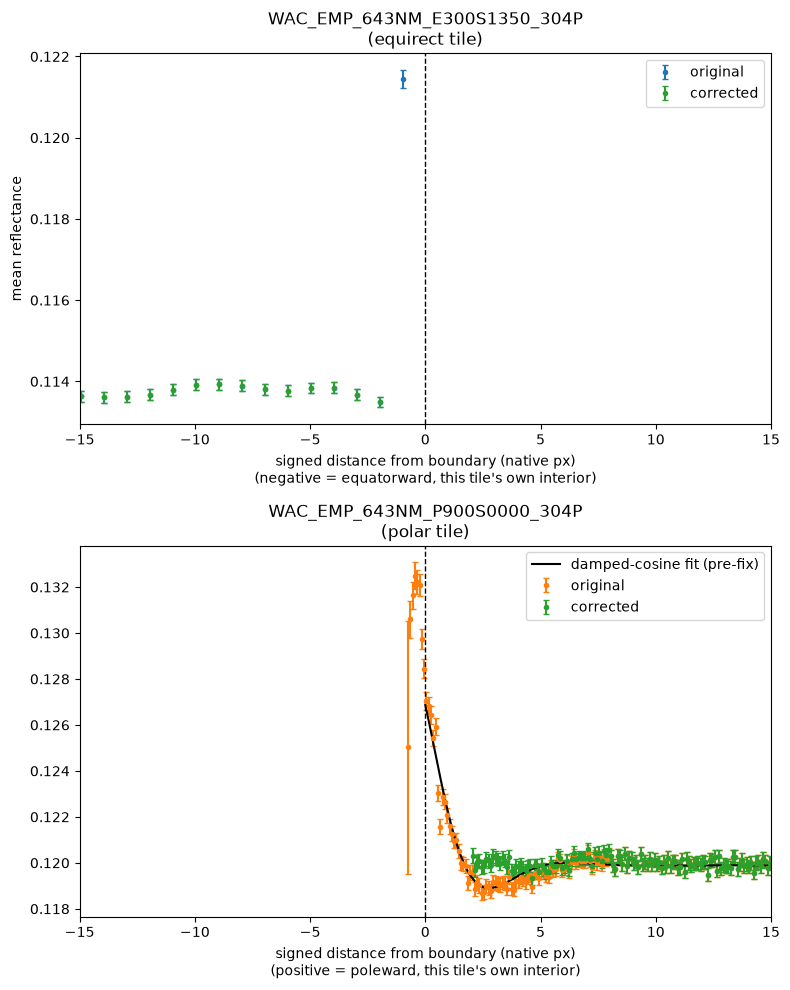

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

axes[0].errorbar(eq_centers, eq_means, yerr=eq_sems, fmt="o", markersize=3, capsize=2, label="original")
axes[0].errorbar(
    eq_centers_corrected,
    eq_means_corrected,
    yerr=eq_sems_corrected,
    fmt="o",
    markersize=3,
    capsize=2,
    color="tab:green",
    label="corrected",
)
axes[0].axvline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_xlim(-MAX_DISTANCE_PX, MAX_DISTANCE_PX)
axes[0].set_xlabel("signed distance from boundary (native px)\n(negative = equatorward, this tile's own interior)")
axes[0].set_ylabel("mean reflectance")
axes[0].set_title(f"{equirect_tile_id}\n(equirect tile)")
axes[0].legend()

axes[1].errorbar(
    pol_centers, pol_means, yerr=pol_sems, fmt="o", markersize=3, capsize=2, color="tab:orange", label="original"
)
axes[1].errorbar(
    pol_centers_corrected,
    pol_means_corrected,
    yerr=pol_sems_corrected,
    fmt="o",
    markersize=3,
    capsize=2,
    color="tab:green",
    label="corrected",
)
x_curve = np.linspace(0, MAX_DISTANCE_PX, 400)
axes[1].plot(
    x_curve, _damped_cosine(x_curve, *fit_params), color="black", linewidth=1.5, label="damped-cosine fit (pre-fix)"
)
axes[1].axvline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_xlim(-MAX_DISTANCE_PX, MAX_DISTANCE_PX)
axes[1].set_xlabel("signed distance from boundary (native px)\n(positive = poleward, this tile's own interior)")
axes[1].set_title(f"{polar_tile_id}\n(polar tile)")
axes[1].legend()

plt.tight_layout()

## Observations

**Equirect tile: a clean single-row spike, not a ramp.** Only the one bin at distance exactly
-1.0px (the tile's own last valid row) is elevated -- every row from -2px inward sits on a flat
~0.1135-0.1140 baseline with no detectable trend, then that one row jumps to ~0.1215 (roughly +7%
over its immediate neighbor, ~+21% over the mean of the 10 rows above it, matching
`wac_emp_seam_investigation.py`'s own figure). Because it's confined to exactly one row, this side
needs no correction curve at all -- masking that single row (or replacing it with the interior
baseline) removes essentially all of it.

**Polar tile: a real overshoot-then-undershoot, not a monotonic edge bump.** Reading outward from
deep in the tile (x > 4px), reflectance sits close to a slowly-varying ~0.119-0.120 baseline. That
baseline itself dips to a local minimum of ~0.119 around x ≈ 1.8-2.5px, rises sharply through
~0.127-0.132 over roughly the last 1.5px before the boundary, and peaks right at/just before it
(x ≈ -0.5 to 0). The peak is at least ~10% above the far baseline, several times larger than the
polar tile's previously-reported "+5.3%" figure -- that number came from comparing only the last
~2px to a 10-35px-back baseline, which understates a peak this sharp and this close to the edge.
This overshoot/undershoot shape (bright right at the edge, measurably *below* baseline a couple of
pixels in, then a slow recovery) is consistent with some kind of edge-ringing from the archived
tile's own production pipeline (e.g. a sharpening or resampling step interacting with a hard data
boundary) rather than a simple radiometric offset -- but this notebook only characterizes the
shape, it doesn't investigate USGS/ASU's own processing to confirm a mechanism.

A handful of bins just poleward of x=0 (as few as 10 samples) sit right at the tile's own true,
sub-pixel raster edge -- consistent with the ~1 native-pixel coverage slop
`wac_emp_seam_investigation.py` already found between the two tiles. Their large error bars are a
real small-sample effect, not evidence the underlying anomaly is weak there.

**For a correction:** the equirect side needs only a one-row mask, no fitted curve. The polar
side's transition zone is real structure spanning several pixels (not a single spike), so a flat
correction factor at the edge would undercorrect the peak and overcorrect the undershoot.

A 4-parameter damped cosine (`baseline + amplitude * exp(-x/tau) * cos(omega*x)`, center pinned to
the boundary itself rather than fit) tracks the poleward tail well: `tau` ≈ 1.5px, `omega` ≈
0.91 rad/px (period ≈ 6.9px), chi2/dof ≈ 1.5 -- close to 1, with the excess consistent with ordinary
terrain texture riding on top of a genuinely smooth underlying curve, not evidence the functional
form is wrong. The one place it doesn't track the data is right at `x=0`: the fitted curve peaks at
`baseline + amplitude` ≈ 0.127 by construction (`cos(0)=1` is its maximum), but the real peak
(~0.132) sits at `x ≈ -0.5`, just outside the fit domain -- the true oscillation likely centers
slightly equatorward of the boundary, but that region's own bins (as few as 10 samples) are too
sparse to fit reliably, so this fit describes the well-sampled poleward tail rather than the exact
peak. That's sufficient for a correction targeting the bulk of affected pixels (`x >= 0`): subtract
`amplitude * exp(-x/tau) * cos(omega*x)` there, and mask outright only the sparse `x < 0` sliver
where no reliable model exists.

**Implemented in its own module, `wac_emp_edge_correction.mask_equirect_edge_row`/
`mask_and_correct_polar_edge`** (kept separate from `ortho_wac_emp.py`'s general reprojection
machinery since this is a fix for one specific, empirically-measured archive defect, not a
structural part of reprojection -- toggleable via `TrntestConfig
.wac_emp_edge_correction_enabled`, in case USGS/ASU ever fix the tiles themselves), **validated
end-to-end in `notebooks/wac_emp_seam_correction_validation.py`.** The green "corrected" points in
the plot above are that actual production code, not a reimplementation -- correcting out to 8px (not
this notebook's original 5px guess: the correction zone alone left a faint secondary dip/rise past
5px, matching the damped cosine's own ~6.9px period) with an 8-13px reference band, and masking
through 2px poleward of the boundary rather than just the sub-pixel overshoot (removing the
worst-corrected pixels outright did more for the seam than any amount of widening or reshaping the
model alone -- see that notebook's own conclusion). That mosaic-level validation found the seam's
own peak jump shrinks 62-65% with the current settings; what's left is explained by the unfit peak
right at `x=0` and a separate tile-precedence-flicker effect this radiometric correction doesn't
touch. The small real coverage gap the masking opens is closed by
`wac_emp_edge_correction.fill_nearby_gaps`, called right after the merge in
`ortho_wac_emp.reproject_wac_emp_reflectance_to_local_grid`.

## Does the same defect appear at the north (+60°) boundary?

Everything above -- and the production correction in `wac_emp_edge_correction.py` -- is
scoped to the south boundary specifically, because the only known-bad `trntest1` entries sit there.
`trntest1` has no entry that actually straddles +60° at all (checked directly against the dataset's
own manifest: 23 entries fall within 5° of -60°, zero within 5° of +60°), so there's no visible
symptom to chase on the north side today. But the working hypothesis is an archive *production*
defect at the equirect/polar tile boundary, which has no obvious reason to respect hemisphere -- so
it's worth checking the archived north tiles directly, the same way the south ones were checked
above, rather than assuming the absence of a known-bad entry means absence of the defect.

Using the north tile at the *same* longitude zone as the south tile profiled above (`E300N1350`
instead of `E300S1350`, both centered at 135°E) for as close to an apples-to-apples comparison as a
single tile pair allows -- a real caveat, since this is one longitude sample per hemisphere, not a
survey across zones.

In [12]:
NORTH_BOUNDARY_LAT_DEG = 60.0
north_equirect_tile_id = "WAC_EMP_643NM_E300N1350_304P"  # matches south's own lon zone (135 deg)
north_polar_tile_id = "WAC_EMP_643NM_P900N0000_304P"
north_equirect_path = cache.fetch_wac_emp_tile(north_equirect_tile_id, config.cache_root, config.wac_emp_base_url)
north_polar_path = cache.fetch_wac_emp_tile(north_polar_tile_id, config.cache_root, config.wac_emp_base_url)
print(north_equirect_tile_id, north_equirect_path)
print(north_polar_tile_id, north_polar_path)

WAC_EMP_643NM_E300N1350_304P /workspace/cache/pds_wac_emp/WAC_EMP_643NM_E300N1350_304P.IMG
WAC_EMP_643NM_P900N0000_304P /workspace/cache/pds_wac_emp/WAC_EMP_643NM_P900N0000_304P.IMG


### North equirect tile: same profile, sign flipped

The north tile covers 0-60°N with the boundary at the tile's own *first* row (row 0) -- the mirror
image of the south tile's last row -- so "equatorward" is the *larger*-row direction here, the
opposite of south. Flipping the sign keeps this notebook's own convention (negative = equatorward,
positive = poleward) consistent across both hemispheres.

In [13]:
with rasterio.open(north_equirect_path) as src:
    north_equirect_transform = src.transform
    north_equirect_crs = src.crs
    north_equirect_height, north_equirect_width = src.height, src.width

(x_boundary_m,), (y_boundary_m,) = warp_transform(geo_crs, north_equirect_crs, [0.0], [NORTH_BOUNDARY_LAT_DEG])
_, north_boundary_row = ~north_equirect_transform * (x_boundary_m, y_boundary_m)
print(f"{north_equirect_tile_id}: boundary row = {north_boundary_row:.2f} (of {north_equirect_height})")

row_lo = max(0, int(math.floor(north_boundary_row - MAX_DISTANCE_PX - 1)))
row_hi = min(north_equirect_height, int(math.ceil(north_boundary_row + MAX_DISTANCE_PX + 1)))
with rasterio.open(north_equirect_path) as src:
    north_equirect_strip = src.read(1, window=Window(0, row_lo, north_equirect_width, row_hi - row_lo))

rows = np.arange(row_lo, row_hi)
north_distance_px_per_row = north_boundary_row - rows  # sign flipped vs. south -- negative = equatorward
valid = north_equirect_strip > SENTINEL_MAGNITUDE_THRESHOLD
north_eq_distance_flat = np.broadcast_to(north_distance_px_per_row[:, None], north_equirect_strip.shape)[valid]
north_eq_value_flat = north_equirect_strip[valid]
print(f"{north_equirect_tile_id}: {north_eq_value_flat.size} valid samples across {row_hi - row_lo} rows")

north_eq_centers, north_eq_means, north_eq_sems, north_eq_counts = _bin_profile(
    north_eq_distance_flat, north_eq_value_flat
)

WAC_EMP_643NM_E300N1350_304P: boundary row = 0.00 (of 18240)
WAC_EMP_643NM_E300N1350_304P: 465120 valid samples across 17 rows


### North polar tile: same radial profile

In [14]:
with rasterio.open(north_polar_path) as src:
    north_polar_transform = src.transform
    north_polar_crs = src.crs
    north_polar_height, north_polar_width = src.height, src.width
    north_center_col, north_center_row = (~north_polar_transform) * (0.0, 0.0)

north_polar_pixel_size_m = abs(north_polar_transform.a)
(x_boundary_m,), (y_boundary_m,) = warp_transform(geo_crs, north_polar_crs, [0.0], [NORTH_BOUNDARY_LAT_DEG])
north_boundary_radius_px = math.hypot(x_boundary_m, y_boundary_m) / north_polar_pixel_size_m
print(f"{north_polar_tile_id}: boundary radius = {north_boundary_radius_px:.2f} px")

north_distance_chunks, north_value_chunks = [], []
with rasterio.open(north_polar_path) as src:
    for row0 in range(0, north_polar_height, STRIP_HEIGHT):
        row1 = min(north_polar_height, row0 + STRIP_HEIGHT)
        strip = src.read(1, window=Window(0, row0, north_polar_width, row1 - row0))
        rows = np.arange(row0, row1).reshape(-1, 1) - north_center_row
        cols = np.arange(north_polar_width).reshape(1, -1) - north_center_col
        radius_px = np.sqrt(rows.astype(np.float64) ** 2 + cols.astype(np.float64) ** 2)
        distance_px = north_boundary_radius_px - radius_px  # positive = poleward
        keep = (strip > SENTINEL_MAGNITUDE_THRESHOLD) & (np.abs(distance_px) <= MAX_DISTANCE_PX)
        if keep.any():
            north_distance_chunks.append(distance_px[keep])
            north_value_chunks.append(strip[keep])

north_pol_distance_flat = np.concatenate(north_distance_chunks)
north_pol_value_flat = np.concatenate(north_value_chunks)
print(f"{north_polar_tile_id}: {north_pol_value_flat.size} valid samples within ±{MAX_DISTANCE_PX}px of the boundary")

north_pol_centers, north_pol_means, north_pol_sems, north_pol_counts = _bin_profile(
    north_pol_distance_flat, north_pol_value_flat
)

WAC_EMP_643NM_P900N0000_304P: boundary radius = 9334.23 px


WAC_EMP_643NM_P900N0000_304P: 879007 valid samples within ±15.0px of the boundary


### Fitting the north polar tile's own shape

Same 4-parameter damped cosine as the south fit above, refit independently -- reusing the south
fit's own parameters here would assume the two hemispheres share not just the same *kind* of defect
but the same magnitude, which the raw profiles plotted below don't support.

In [15]:
north_fit_mask = (north_pol_centers >= 0) & (north_pol_counts >= MIN_FIT_BIN_COUNT)
north_x_fit = north_pol_centers[north_fit_mask]
north_y_fit = north_pol_means[north_fit_mask]
north_sigma_fit = north_pol_sems[north_fit_mask]

north_initial_guess = [0.126, 0.002, 2.0, 1.5]  # baseline, amplitude, tau (px), omega (rad/px)
north_fit_params, north_fit_cov = curve_fit(
    _damped_cosine, north_x_fit, north_y_fit, p0=north_initial_guess, sigma=north_sigma_fit, absolute_sigma=True
)
north_fit_errs = np.sqrt(np.diag(north_fit_cov))
north_baseline_fit, north_amplitude_fit, north_tau_fit, north_omega_fit = north_fit_params

north_fit_residuals = north_y_fit - _damped_cosine(north_x_fit, *north_fit_params)
north_fit_chi2 = float(np.sum((north_fit_residuals / north_sigma_fit) ** 2))
north_fit_dof = len(north_x_fit) - len(north_fit_params)
print(f"baseline  = {north_baseline_fit:.5f} ± {north_fit_errs[0]:.5f}")
print(f"amplitude = {north_amplitude_fit:.5f} ± {north_fit_errs[1]:.5f}")
print(f"tau       = {north_tau_fit:.3f} ± {north_fit_errs[2]:.3f} px")
print(
    f"omega     = {north_omega_fit:.3f} ± {north_fit_errs[3]:.3f} rad/px  (period = {2 * np.pi / north_omega_fit:.2f} px)"
)
print(f"chi2/dof  = {north_fit_chi2:.1f} / {north_fit_dof} = {north_fit_chi2 / north_fit_dof:.2f}")

baseline  = 0.12583 ± 0.00003
amplitude = 0.00179 ± 0.00015
tau       = 4.047 ± 0.456 px
omega     = 1.021 ± 0.019 rad/px  (period = 6.15 px)
chi2/dof  = 408.6 / 146 = 2.80


### Plot: south vs north, same axes

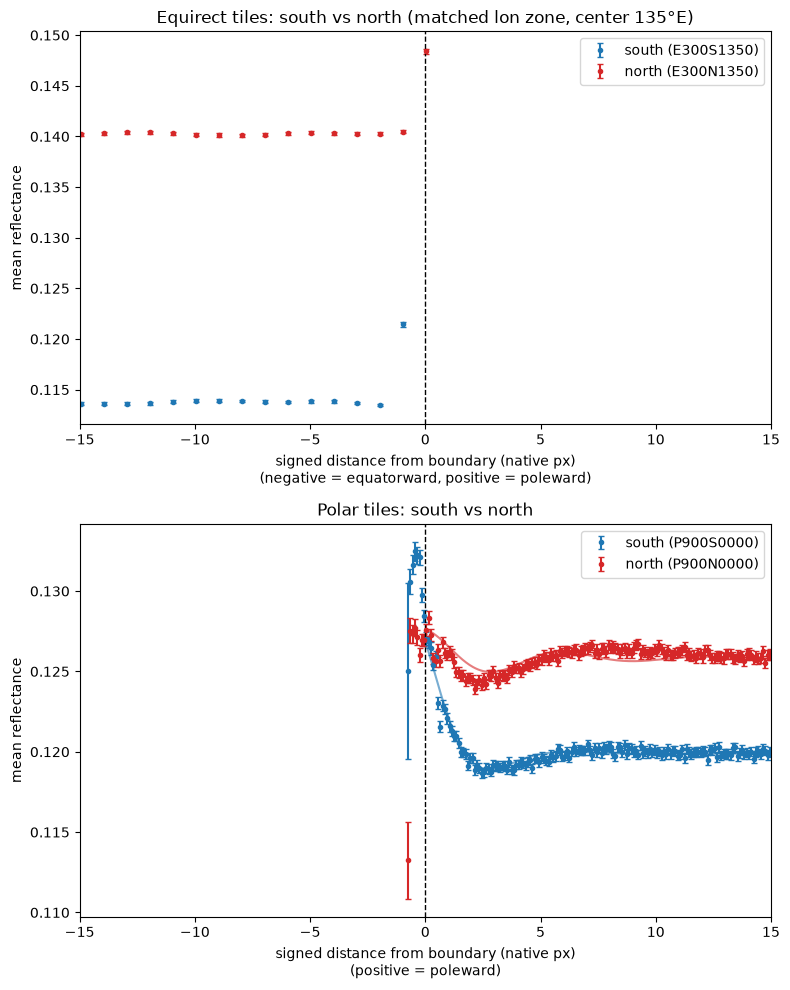

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

axes[0].errorbar(
    eq_centers, eq_means, yerr=eq_sems, fmt="o", markersize=3, capsize=2, label="south (E300S1350)", color="tab:blue"
)
axes[0].errorbar(
    north_eq_centers,
    north_eq_means,
    yerr=north_eq_sems,
    fmt="o",
    markersize=3,
    capsize=2,
    label="north (E300N1350)",
    color="tab:red",
)
axes[0].axvline(0, color="black", linewidth=1, linestyle="--")
axes[0].set_xlim(-MAX_DISTANCE_PX, MAX_DISTANCE_PX)
axes[0].set_xlabel("signed distance from boundary (native px)\n(negative = equatorward, positive = poleward)")
axes[0].set_ylabel("mean reflectance")
axes[0].set_title("Equirect tiles: south vs north (matched lon zone, center 135°E)")
axes[0].legend()

axes[1].errorbar(
    pol_centers, pol_means, yerr=pol_sems, fmt="o", markersize=3, capsize=2, label="south (P900S0000)", color="tab:blue"
)
axes[1].errorbar(
    north_pol_centers,
    north_pol_means,
    yerr=north_pol_sems,
    fmt="o",
    markersize=3,
    capsize=2,
    label="north (P900N0000)",
    color="tab:red",
)
x_curve = np.linspace(0, MAX_DISTANCE_PX, 400)
axes[1].plot(x_curve, _damped_cosine(x_curve, *fit_params), color="tab:blue", linewidth=1.5, alpha=0.6)
axes[1].plot(x_curve, _damped_cosine(x_curve, *north_fit_params), color="tab:red", linewidth=1.5, alpha=0.6)
axes[1].axvline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_xlim(-MAX_DISTANCE_PX, MAX_DISTANCE_PX)
axes[1].set_xlabel("signed distance from boundary (native px)\n(positive = poleward)")
axes[1].set_ylabel("mean reflectance")
axes[1].set_title("Polar tiles: south vs north")
axes[1].legend()

plt.tight_layout()

## North-hemisphere observations

**Same kind of defect on both tiles, real but smaller magnitude on this one sampled longitude.**

The north equirect tile shows the identical clean single-row spike as south -- one bin elevated
(0.1402 baseline -> 0.1484 at the boundary row, +5.8%), flat everywhere else -- just a smaller jump
than south's own (0.1135 -> 0.1215, +7.0% by the same immediate-neighbor comparison; south's
previously-reported +21%/+12% used a 10-row-back baseline instead, not directly comparable here, but
either way south's is the bigger jump). Not a fluke of one row: same shape, same mechanism, weaker
effect.

The north polar tile shows the same overshoot-dip-recovery shape as south's damped cosine, but the
fit makes the size difference concrete: amplitude 0.00179 vs. south's 0.00706 (~4x smaller), tau
4.05px vs. 1.54px (a slower, more spread-out decay rather than a sharp near-boundary peak), omega
1.02 vs. 0.91 rad/px (similar period, ~6.2px vs. ~6.9px). chi2/dof is worse (2.80 vs. 1.17) -- the
smaller amplitude means the ringing is closer to the noise floor here, harder for a clean damped
cosine to track precisely, but the fit still converges to a sensible, visually-matching curve (see
the red curve on the plot above).

**Implication for generalizing the correction:** reusing south's fitted amplitude/tau/omega for a
hypothetical north correction would substantially over-correct -- confirming the concern raised
before running this. A real north correction would need this fit (or a better one, ideally averaged
over more than one longitude zone) as its own starting point, not a copy of south's numbers. Given
`trntest1` has no entry that actually straddles +60° to validate against, and no visible artifact to
fix today, writing that correction is left as a follow-on rather than done here -- this notebook's
job was answering *whether* the concern was real, and it is.